In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

score_df = pd.read_csv("student-score-outlier.csv")

In [2]:
# Task 1: Load and Inspect the Dataset
display(score_df.head(10))
print("Shape:", score_df.shape)
print("\nData types:")
print(score_df.dtypes)
print("\nMissing values:")
print(score_df.isna().sum())

,HW,Lab,Quiz,Midterm,Final
0,2.4,14.7,18.0,15.0,18.4
1,8.3,14.6,4.5,3.4,3.3
2,1.5,14.1,8.7,4.1,10.6
3,8.1,15.0,3.5,12.8,5.5
4,9.9,13.7,12.0,13.4,7.4
5,0.1,14.4,20.0,18.1,8.5
6,2.1,0.0,8.0,8.4,7.9
7,7.0,14.8,5.5,4.4,5.7
8,7.1,6.5,2.6,1.3,0.9
9,1.4,13.3,9.3,5.3,78.0


Shape: (25, 5)

Data types:
HW         float64
Lab        float64
Quiz       float64
Midterm    float64
Final      float64
dtype: object

Missing values:
HW         0
Lab        0
Quiz       0
Midterm    0
Final      0
dtype: int64


In [3]:
# Questions
## Provide your answers in a Markdown cell.
## 1. How many rows and columns are in the dataset?
### 25 Rows, 5 Columns

## 2. Are all score columns stored as numerical data?
### Yes

## 3. Does the dataset contain missing values?
### No

In [4]:
# Task 2: Validate Scores Using Domain Rules
score_limits = {
    "HW": (0, 30),
    "Lab": (0, 15),
    "Quiz": (0, 25),
    "Midterm": (0, 25),
    "Final": (0, 35)
}

for column, (lower, upper) in score_limits.items():
    invalid = score_df.loc[
        ~score_df[column].between(lower, upper)
    ]

    print(f"\n{column}: valid range = {lower}–{upper}")
    display(invalid)


HW: valid range = 0–30


,HW,Lab,Quiz,Midterm,Final



Lab: valid range = 0–15


,HW,Lab,Quiz,Midterm,Final



Quiz: valid range = 0–25


,HW,Lab,Quiz,Midterm,Final



Midterm: valid range = 0–25


,HW,Lab,Quiz,Midterm,Final
20,1.9,15.0,24.1,-17.0,33.3



Final: valid range = 0–35


,HW,Lab,Quiz,Midterm,Final
9,1.4,13.3,9.3,5.3,78.0


In [5]:
# Questions
## 1. Which values clearly violate the Domain Rules?
### Row 9 that has Midterm scores -17.0 but the range was (0-25) and Row 20 that has Final scores 78.0 but the range was (0-35)

## 2. Can a value be unusual but still remain within its valid range? Provide one example.
### Yes, it can be all scores are max but it's still in valid range.

## 3. Why should Domain Rules be checked before statistical outlier-detection methods?
### Because, it can filter out whether the value is valid or violates the conditions.

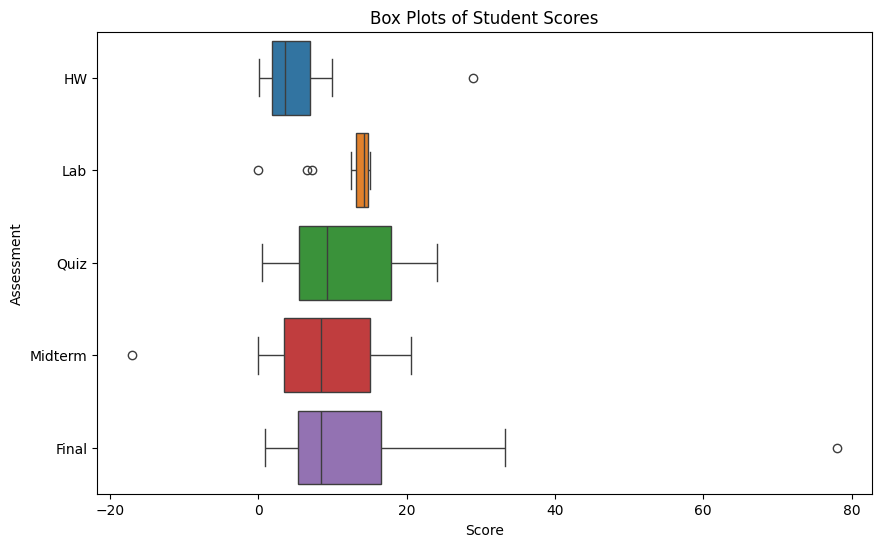

In [6]:
# Task 3: Explore the Data Using Visualization
## Task 3.1: Box Plots of All Score Variables
### Create a horizontal Box Plot for all five score columns.
score_columns = ["HW", "Lab", "Quiz", "Midterm", "Final"]

plt.figure(figsize=(10, 6))
sns.boxplot(data=score_df[score_columns], orient="h")
plt.title("Box Plots of Student Scores")
plt.xlabel("Score")
plt.ylabel("Assessment")
plt.show()

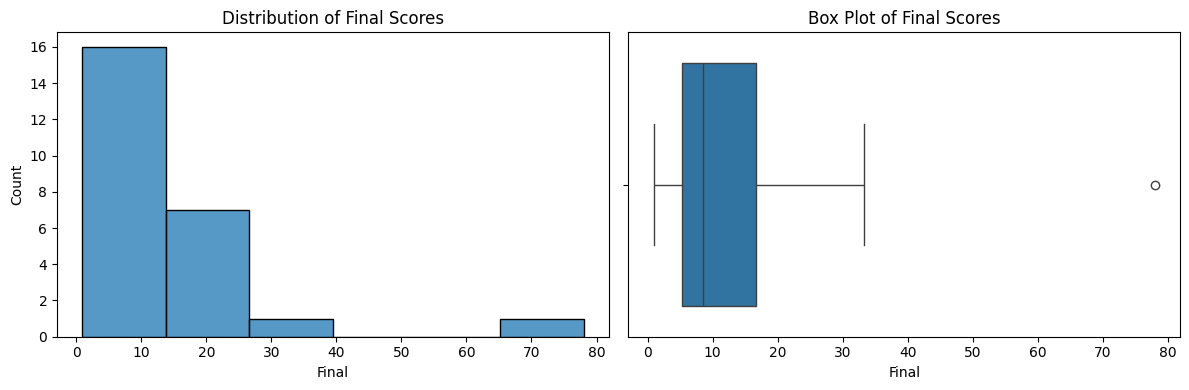

In [7]:
## Task 3.2: Inspect the Final Score from Two Perspectives
### Create a Histogram and a Box Plot for Final.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data=score_df,
    x="Final",
    bins=6,
    ax=axes[0]
)
axes[0].set_title("Distribution of Final Scores")

sns.boxplot(
    data=score_df,
    x="Final",
    ax=axes[1]
)
axes[1].set_title("Box Plot of Final Scores")

plt.tight_layout()
plt.show()

In [8]:
# Questions
## 1. Which observations are displayed outside the Whiskers?
### HW, Lab, Midterm, Final.

## 2. What does the Histogram reveal that is less obvious in the Box Plot?
### The numbers of students's scores in final exam.

## 3. Are all points outside the Whiskers invalid according to the Domain Rules?
### No, because it's just invalid domain rules but doesn't mean it is a invalid or error data because it can be used for other use cases.

## 4. Explain why a point outside the Whiskers should be called a Potential Outlier rather than an error.
### Because, it can be real data or be used in other use cases.

In [9]:
# Task 4: Detect Potential Outliers Using Z-score
## Potential Outlier: |Z-score| ≥ 3 (Rule)
z_scores = (
    score_df[score_columns] - score_df[score_columns].mean()
) / score_df[score_columns].std()

zscore_flag = z_scores.abs() >= 3

zscore_row_flag = zscore_flag.any(axis=1)
zscore_outliers = score_df.loc[zscore_row_flag]

display(zscore_outliers)

,HW,Lab,Quiz,Midterm,Final
6,2.1,0.0,8.0,8.4,7.9
9,1.4,13.3,9.3,5.3,78.0
14,29.0,7.2,0.5,0.0,1.8
20,1.9,15.0,24.1,-17.0,33.3


In [10]:
# Questions
## 1. Which records are flagged by Z-score?
###  Record 6, 9, 14 and 20.

## 2. Which score columns caused each record to be flagged?
### Record 6: Lab (0.0)
### Record 9: Final (78.0).
### Record 14: Midterm (0.0).
### Record 20: Midterm (-17.0)

## 3. Are all flagged values outside their valid ranges?
### No, Record 6 & Record 14 are in their valid ranges.

## 4. What limitations of Z-score should be considered for this dataset of only 25 records?
###  Extreme Sensitivity, Normality Assumption and Mathematical Limits.

In [11]:
# Task 5: Detect Potential Outliers Using IQR
## Lower Fence = Q1 − 1.5 × IQR
## Upper Fence = Q3 + 1.5 × IQR
q1 = score_df[score_columns].quantile(0.25)
q3 = score_df[score_columns].quantile(0.75)
iqr = q3 - q1

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

iqr_flag = (
    (score_df[score_columns] < lower_fence) |
    (score_df[score_columns] > upper_fence)
)

iqr_row_flag = iqr_flag.any(axis=1)
iqr_outliers = score_df.loc[iqr_row_flag]

display(iqr_outliers)

fences = pd.DataFrame({
    "Lower Fence": lower_fence,
    "Upper Fence": upper_fence
})

display(fences)

,HW,Lab,Quiz,Midterm,Final
6,2.1,0.0,8.0,8.4,7.9
8,7.1,6.5,2.6,1.3,0.9
9,1.4,13.3,9.3,5.3,78.0
14,29.0,7.2,0.5,0.0,1.8
20,1.9,15.0,24.1,-17.0,33.3


,Lower Fence,Upper Fence
HW,-6.00,14.80
Lab,10.80,17.20
Quiz,-13.10,36.50
Midterm,-14.00,32.40
Final,-11.65,33.55


In [12]:
# Questions
## 1. Which records are flagged by IQR?
### Record 6, 8, 9, 14 and 20.

## 2. Which records are detected by both Z-score and IQR?
### Record 6, 9, 14 and 20.

## 3. Which records are detected by only one method?
### Record 8.

## 4. Why might Z-score and IQR produce different results?
### Z-score is easily distorted by extreme values because it relies on the average, whereas IQR remains stable by only measuring the spread of the middle 50% of your data, ignoring the extreme tails completely.

In [13]:
# Task 6: Detect Multivariate Outliers Using Isolation Forest
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=100,
    contamination="auto",
    random_state=42
)

labels = model.fit_predict(
    score_df[score_columns]
)

scores = model.decision_function(
    score_df[score_columns]
)

isolation_result = score_df.assign(
    anomaly_score=scores,
    potential_outlier=(labels == -1)
).sort_values("anomaly_score")

display(isolation_result)

display(
    isolation_result[
        isolation_result["potential_outlier"]
    ]
)

,HW,Lab,Quiz,Midterm,Final,anomaly_score,potential_outlier
14,29.0,7.2,0.5,0.0,1.8,-0.151838,True
20,1.9,15.0,24.1,-17.0,33.3,-0.115439,True
9,1.4,13.3,9.3,5.3,78.0,-0.079544,True
6,2.1,0.0,8.0,8.4,7.9,-0.075014,True
19,0.2,14.1,22.7,15.9,26.0,-0.013365,True
8,7.1,6.5,2.6,1.3,0.9,-0.012851,True
18,8.8,15.0,19.4,20.6,17.7,0.004011,False
5,0.1,14.4,20.0,18.1,8.5,0.019046,False
4,9.9,13.7,12.0,13.4,7.4,0.039274,False
22,0.7,14.8,17.9,12.5,20.1,0.052017,False


,HW,Lab,Quiz,Midterm,Final,anomaly_score,potential_outlier
14,29.0,7.2,0.5,0.0,1.8,-0.151838,True
20,1.9,15.0,24.1,-17.0,33.3,-0.115439,True
9,1.4,13.3,9.3,5.3,78.0,-0.079544,True
6,2.1,0.0,8.0,8.4,7.9,-0.075014,True
19,0.2,14.1,22.7,15.9,26.0,-0.013365,True
8,7.1,6.5,2.6,1.3,0.9,-0.012851,True


In [14]:
# Questions
## 1. Which records have the five lowest Anomaly Scores?
### Record 14, 20, 9, 6 and 19.

## 2. Which records are classified as Potential Outliers?
### Record 14, 20, 9, 6, 19 and 8.

## 3. Are any records identified only by Isolation Forest but not by Z-score or IQR?
### Record 19.

## 4. What combination of scores might make those records unusual?
### Midterm (Negative Scores) & Final Scores (More than limit).

## 5. Does potential_outlier=True prove that the record is incorrect? Explain.
### No, potential_outlier=True only indicates that a record is statistically unusual or rare compared to the rest of the dataset, not that it violates the strict score_limits rules.

In [15]:
# Task 7: Compare and Investigate the Flagged Records
# Required Reflection
# Answer the following questions:

## 1. Which records clearly contain data-quality errors?
### Record 9 because final scores has more than limit (78.0/35), 
### Record 20 because midterm scores has negative scores (-17.0/25).

## 2. Which records appear unusual but may still be valid?
### Record 6, 8, 14 and 19

## 3. Did all detection methods agree? Why or why not?
### No, the detection methods disagreed because they measure completely different concepts of wrong.

## 4. Which evidence had the greatest influence on your decisions?
### The score_limits dictionary provided the most definitive evidence. Statistical tools like Z-scores and anomaly scores are excellent for highlighting suspicious records that warrant manual review, but only domain knowledge (knowing that a test cannot be scored below 0 or above 35) can absolutely confirm a data entry error.

In [16]:
# Task 8: Apply the Selected Treatments
raw_score_df = score_df.copy()
clean_score_df = score_df.copy()

In [17]:
# Example: replace an invalid value with Missing when the correct value is unknown
clean_score_df.loc[9, "Final"] = np.nan

# Example: add a flag while retaining a valid but unusual record
clean_score_df["requires_review"] = False
clean_score_df.loc[[6, 8, 14, 19], "requires_review"] = True

# Example: remove a record only when removal is justified
clean_score_df = clean_score_df.drop(index=[20])

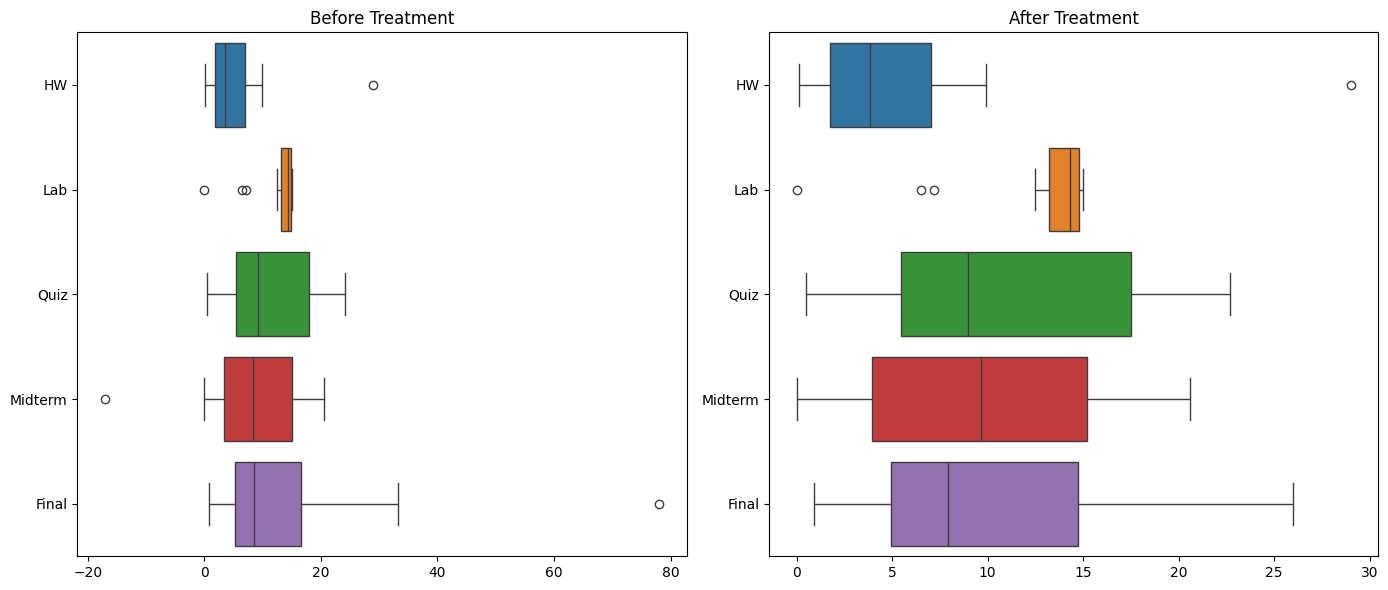

In [18]:
# Task 9: Review the Data After Treatment
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(
    data=raw_score_df[score_columns],
    orient="h",
    ax=axes[0]
)
axes[0].set_title("Before Treatment")

sns.boxplot(
    data=clean_score_df[score_columns],
    orient="h",
    ax=axes[1]
)
axes[1].set_title("After Treatment")

plt.tight_layout()
plt.show()

In [ ]:
# Questions
## 1. Which confirmed errors were handled?
### The extreme errors in the Midterm (-17.0) and Final (78.0) columns were successfully handled.

## 2. Which Potential Outliers remain in the cleaned data?
### The high HW score (29.0) and the unusually low Lab scores (0.0, 6.5, and 7.2) remain in the dataset.

## 3. Why is it appropriate to retain those observations?
### These remaining outliers fall strictly within the valid grading bounds. While they behave differently than the rest of the class, they represent realistic academic scenarios.

## 4. How did the selected treatments affect the Distributions?
### Removing the extreme errors uncompressed the visual distributions. In the Before Treatment plot, the massive scale required to show -17 and 78 forced the boxes (the interquartile ranges) to look squashed, hiding the true variance of the data. By dropping those two errors, the After Treatment axes naturally rescaled, allowing the true spread, medians, and density of the valid scores to expand and become clearly readable.

In [20]:
# Part B: Categorical and Text Data
# Task 10: Load and Select Variables from the Titanic Dataset
titanic_df = pd.read_csv("titanic-data-miss.csv")

display(titanic_df.head())
print("Shape:", titanic_df.shape)
print(titanic_df.isna().sum())

selected_columns = [
    "PassengerId",
    "Survived",
    "Pclass",
    "Name",
    "Sex",
    "Age",
    "Fare",
    "Embarked"
]

titanic_df = titanic_df[selected_columns].copy()

titanic_df["Embarked"] = (
    titanic_df["Embarked"]
    .fillna("Unknown")
)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Shape: (891, 12)
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex             43
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
# Questions
## 1. How many Missing values exist in each selected column?
### Sex - 43
### Age - 177
### Cabin - 687
### Embarked - 2

## 2. Why is dropping every row containing any Missing value inappropriate for this task?
### Because it may destroys your data, The Cabin column is missing 687 values. This means dropping rows will instantly wipe out over three-quarters of your entire dataset just because of this single feature.

In [ ]:
# Task 11: Classify the Variables
# Classify each selected variable using one of the following types:

## Passenger - Identifier
## Survived	- Binary
## Pclass - Ordinal
## Name	- High-cardinality Text
## Sex - Binary
## Age - Numerical
## SibSp - Numerical
## Parch - Numerical
## Ticket - High-cardinality Text
## Fare	- Numerical
## Cabin - High-cardinality Text
## Embarked	- Nominal


In [ ]:
# Questions
## 1. Why should PassengerId not be One-hot Encoded?
### Because it has high cardinality, meaning it contains thousands or millions of unique values.

## 2. Why should Name not be One-hot Encoded directly?
### Because it has high cardinality, which creates massive memory usage, severe overfitting, and the curse of dimensionality.

## 3. Although Pclass is stored as a number, why can it be considered Categorical Data?
### Because it's an ordinal data which mean the categories are encoded as a number (label).

## 4. Which columns are suitable for One-hot Encoding in this exercise?
### Age, Embarked because it designed specifically for data with low cardinality (few unique categories) that have no inherent mathematical order.

In [24]:
# Task 12: Apply One-hot Encoding with pd.get_dummies()
print("Before encoding:", titanic_df.shape)

Before encoding: (891, 8)


In [25]:
titanic_encoded = pd.get_dummies(
    titanic_df,
    columns=["Sex", "Embarked"],
    dtype=int
)

print("After encoding:", titanic_encoded.shape)
display(titanic_encoded.head())

After encoding: (891, 12)


,PassengerId,Survived,Pclass,Name,Age,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Embarked_Unknown
0,1,0,3,"Braund, Mr. Owen Harris",22.0,7.2500,0,1,0,0,1,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,71.2833,1,0,1,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,7.9250,1,0,0,0,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,53.1000,1,0,0,0,1,0
4,5,0,3,"Allen, Mr. William Henry",35.0,8.0500,0,1,0,0,1,0


In [ ]:
# Questions
## 1. Which new columns were created?
### Sex_female, Sex_male, Embarked_C, Embarked_Q, Embarked_S and Embarked_Unknown

## 2. What happened to the original Sex and Embarked columns?
### It got replaced with One-hot encoded columns.

## 3. How many columns existed before and after encoding?
### 8 Columns Existed before and 12 Columns after encoding

## 4. Why is One-hot Encoding appropriate for Sex and Embarked?
### Both are nominal categorical variables, meaning they have distinct groups but no inherent mathematical ranking.

## 5. Why did we not apply One-hot Encoding to PassengerId and Name?
### Because they are identifiers with incredibly high cardinality and it can caused curse of dimensionality.

In [27]:
# Task 13: Text Processing with Regular Expression
## The Name column contains titles such as Mr, Mrs, and Miss. Extract the title into a new column named Title.
titanic_df["Title"] = titanic_df["Name"].str.extract(
    r",\s*([^.]*)\."
)

display(
    titanic_df[["Name", "Title"]].head(10)
)

display(
    titanic_df["Title"].value_counts()
)

,Name,Title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr
5,"Moran, Mr. James",Mr
6,"McCarthy, Mr. Timothy J",Mr
7,"Palsson, Master. Gosta Leonard",Master
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Mrs
9,"Nasser, Mrs. Nicholas (Adele Achem)",Mrs


Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [ ]:
# Questions
## 1. How many unique titles were extracted?
### 10

## 2. Which titles appear most frequently?
### Mr

## 3. Are there titles that appear only a few times?
### Yes, like Ms (1), Col (2), Mlle (2) and Major(2)

## 4. Why might extracting Title be more useful than One-hot Encoding the complete Name column?
### The original Name column acts as a high-cardinality identifier because almost every row contains a unique string. By extracting the title, you engineer a powerful, low-cardinality categorical feature that effectively groups passengers by social status, implied age, and gender without bloating the dataset.

In [ ]:
# Final Reflection
## 1. What is the difference between a value that violates a Domain Rule and a Potential Outlier identified statistically?
### A domain rule violation is a logical or physical impossibility it is definitively wrong.
### A statistical outlier is mathematically rare but possible it can still be a completely valid.

## 2. Why can Z-score, IQR, and Isolation Forest identify different records?
### Z-score: Measures distance from the mean. It assumes a symmetrical bell curve and is easily masked by a single massive typo that drags the average up.
### IQR: Measures distance from the median using the middle 50% of the data. It makes no assumptions about data shape and entirely ignores extreme tails, making it highly stable.
### Isolation Forest: A tree-based machine learning model that looks at multivariate patterns. It flags records not just for being exceptionally high or low in one column, but for exhibiting rare combinations of features across multiple columns.

## 3. Why should raw data be preserved before cleaning?
### Raw data is your immutable ground truth and ultimate fail-safe. If an imputation strategy introduces bias, an algorithm accidentally drops valid rows, or business constraints shift later in the project, preserving the original state ensures you can always roll back, audit, and reproduce the pipeline without permanently destroying information.

## 4. What information should be documented when a value is corrected, replaced, retained, or removed?
### The exact location (Row ID/Index and Column Name).
### The original raw value.
### The specific treatment applied (e.g., dropped, median-imputed, capped at a threshold).
### The new resulting value.
### The exact justification or rule that triggered the change (e.g., "Failed domain rule: Age < 0", or "Z-score > 3").

## 5. What is one limitation of One-hot Encoding?
### The primary flaw is the curse of dimensionality. If applied to a categorical variable with high cardinality, it will spawn hundreds or thousands of new, mostly empty binary columns.